# Week 6: TrashNet Fine-Tuning – Pass 1

## Objective

The objective of this notebook is to perform the first fine-tuning pass on the TrashNet image classification model developed during Week 6 feature extraction.

Instead of training only the custom classification head, the top layers of the pre-trained EfficientNetB0 model are unfrozen and fine-tuned using a small learning rate to improve feature representations for the TrashNet dataset.

---

## Model Information

- **Model:** EfficientNetB0
- **Transfer Learning:** Fine-Tuning
- **Dataset:** TrashNet
- **Number of Classes:** 6
  - Cardboard
  - Glass
  - Metal
  - Paper
  - Plastic
  - Trash

---

## Fine-Tuning Configuration

- **Input Image Size:** 224 × 224
- **Batch Size:** 32
- **Learning Rate:** 1e-5
- **Optimizer:** Adam
- **Loss Function:** Sparse Categorical Crossentropy
- **Unfrozen Layers:** Top 30 layers of EfficientNetB0
- **Epochs:** 5
- **Callbacks:**
  - EarlyStopping
  - ReduceLROnPlateau

---

## Expected Outcome

The purpose of this experiment is to compare the performance of the fine-tuned model with the feature extraction model and determine whether fine-tuning improves the model's generalization on the TrashNet dataset.

The evaluation includes:
- Training Accuracy
- Validation Accuracy
- Accuracy and Loss Curves
- Confusion Matrix
- Classification Report

The saved model from this notebook will be used as a checkpoint for the deeper fine-tuning experiments in Week 7.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os

from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

In [5]:
print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


In [6]:
DATASET_PATH = "/content/drive/MyDrive/data/trashnet"

In [7]:
print(os.listdir(DATASET_PATH))

['trash', 'glass', 'cardboard', 'metal', 'plastic', 'paper']


In [8]:
IMG_SIZE = (224,224)
BATCH_SIZE = 32
SEED = 42

In [9]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 2527 files belonging to 6 classes.
Using 2022 files for training.
Found 2527 files belonging to 6 classes.
Using 505 files for validation.


In [10]:
class_names = train_dataset.class_names

print(class_names)

['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


In [11]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
validation_dataset = validation_dataset.prefetch(buffer_size=AUTOTUNE)

In [12]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2)
])

In [13]:
base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [14]:
base_model.trainable = False

In [15]:
print("Base model trainable:", base_model.trainable)

Base model trainable: False


In [16]:
inputs = tf.keras.Input(shape=(224, 224, 3))

x = data_augmentation(inputs)

x = tf.keras.applications.efficientnet.preprocess_input(x)

x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dropout(0.3)(x)

outputs = layers.Dense(
    len(class_names),
    activation="softmax"
)(x)

model = Model(inputs, outputs)

In [17]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │         7,686 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,057,257 (15.48 MB)

 Trainable params: 7,686 (30.02 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [18]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [19]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=2,
    verbose=1
)

In [20]:
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=20,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 431s 7s/step - accuracy: 0.6137 - loss: 1.0849 - val_accuracy: 0.7822 - val_loss: 0.6802 - learning_rate: 0.0010
Epoch 2/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 10s 155ms/step - accuracy: 0.7794 - loss: 0.6497 - val_accuracy: 0.8218 - val_loss: 0.5322 - learning_rate: 0.0010
Epoch 3/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 11s 165ms/step - accuracy: 0.8249 - loss: 0.5202 - val_accuracy: 0.8277 - val_loss: 0.4861 - learning_rate: 0.0010
Epoch 4/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 10s 151ms/step - accuracy: 0.8412 - loss: 0.4752 - val_accuracy: 0.8455 - val_loss: 0.4483 - learning_rate: 0.0010
Epoch 5/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 10s 149ms/step - accuracy: 0.8531 - loss: 0.4334 - val_accuracy: 0.8634 - val_loss: 0.4192 - learning_rate: 0.0010
Epoch 6/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 11s 171ms/step - accuracy: 0.8670 - loss: 0.3990 - val_accuracy: 0.8594 - val_loss: 0.4091 - learning_rate: 0.0010
Epoch 7/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 12s 195ms/step - accuracy: 0.8605 - loss: 0.39

In [21]:
# Final Training Accuracy
train_acc = history.history["accuracy"][-1]

# Final Validation Accuracy
val_acc = history.history["val_accuracy"][-1]

print(f"Training Accuracy: {train_acc*100:.2f}%")
print(f"Validation Accuracy: {val_acc*100:.2f}%")

Training Accuracy: 91.89%
Validation Accuracy: 88.12%


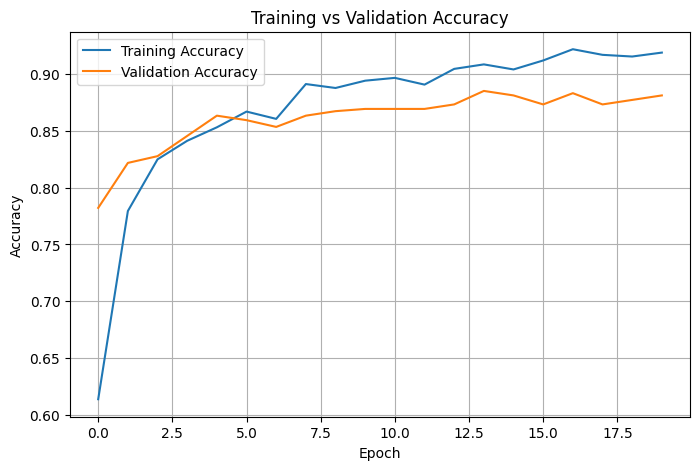

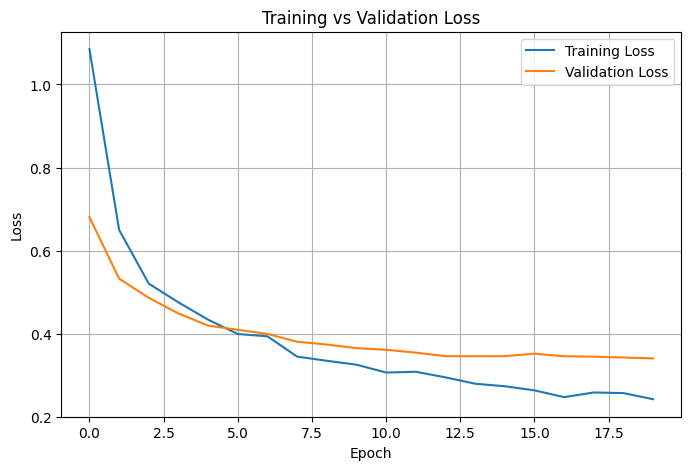

In [22]:
import matplotlib.pyplot as plt

# Accuracy Plot
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Loss Plot
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [23]:
# Save complete model
model.save("trashnet_feature_extraction.keras")

# Save weights
model.save_weights("trashnet_feature_extraction.weights.h5")

print("Model and weights saved successfully!")

Model and weights saved successfully!


In [24]:
model.save("/content/drive/MyDrive/trashnet_feature_extraction.keras")
model.save_weights("/content/drive/MyDrive/trashnet_feature_extraction.weights.h5")

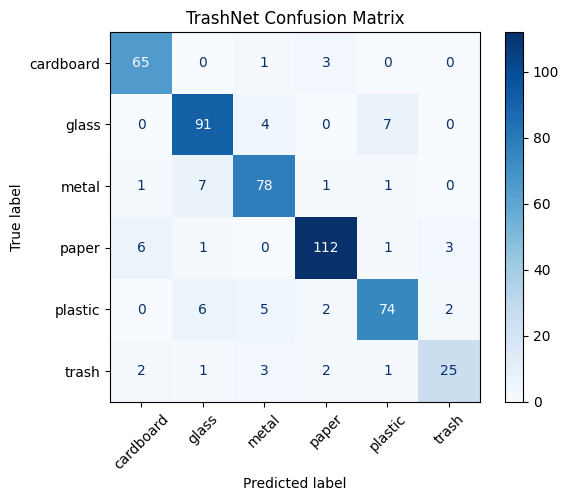

In [25]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_true = []
y_pred = []

for images, labels in validation_dataset:
    predictions = model.predict(images, verbose=0)
    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("TrashNet Confusion Matrix")
plt.show()

In [26]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

              precision    recall  f1-score   support

   cardboard       0.88      0.94      0.91        69
       glass       0.86      0.89      0.88       102
       metal       0.86      0.89      0.87        88
       paper       0.93      0.91      0.92       123
     plastic       0.88      0.83      0.86        89
       trash       0.83      0.74      0.78        34

    accuracy                           0.88       505
   macro avg       0.87      0.87      0.87       505
weighted avg       0.88      0.88      0.88       505



In [27]:
model.save_weights("/content/drive/MyDrive/trashnet_feature_extraction.weights.h5")

In [28]:
model.load_weights("/content/drive/MyDrive/trashnet_feature_extraction.weights.h5")

In [29]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

for layer in base_model.layers[-30:]:
    layer.trainable = True

In [30]:
print("Trainable layers:",
      sum(layer.trainable for layer in base_model.layers))

Trainable layers: 30


In [31]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [32]:
history_finetune = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=5,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 32s 198ms/step - accuracy: 0.8417 - loss: 0.4824 - val_accuracy: 0.8673 - val_loss: 0.3473 - learning_rate: 1.0000e-05
Epoch 2/5
63/64 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - accuracy: 0.8275 - loss: 0.4887
Epoch 2: ReduceLROnPlateau reducing learning rate to 2.9999999242136253e-06.
64/64 ━━━━━━━━━━━━━━━━━━━━ 11s 165ms/step - accuracy: 0.8393 - loss: 0.4739 - val_accuracy: 0.8733 - val_loss: 0.3603 - learning_rate: 1.0000e-05
Epoch 3/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 10s 154ms/step - accuracy: 0.8709 - loss: 0.4192 - val_accuracy: 0.8634 - val_loss: 0.3772 - learning_rate: 3.0000e-06
Epoch 4/5
63/64 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - accuracy: 0.8624 - loss: 0.4270
Epoch 4: ReduceLROnPlateau reducing learning rate to 8.999999636216671e-07.
64/64 ━━━━━━━━━━━━━━━━━━━━ 10s 145ms/step - accuracy: 0.8675 - loss: 0.4175 - val_accuracy: 0.8634 - val_loss: 0.3883 - learning_rate: 3.0000e-06
Epoch 5/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 10s 163ms/step - accuracy: 0.8655 - 

In [33]:
print(f"Training Accuracy: {history_finetune.history['accuracy'][-1]*100:.2f}%")
print(f"Validation Accuracy: {history_finetune.history['val_accuracy'][-1]*100:.2f}%")

Training Accuracy: 86.55%
Validation Accuracy: 85.94%


In [35]:
model.save("/content/drive/MyDrive/trashnet_finetuning_pass1.keras")
model.save_weights("/content/drive/MyDrive/trashnet_finetuning_pass1.weights.h5")

print("Fine-tuning model saved successfully!")

Fine-tuning model saved successfully!


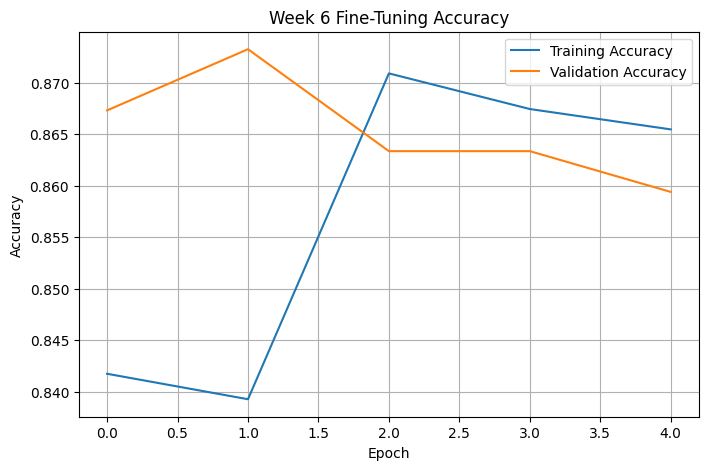

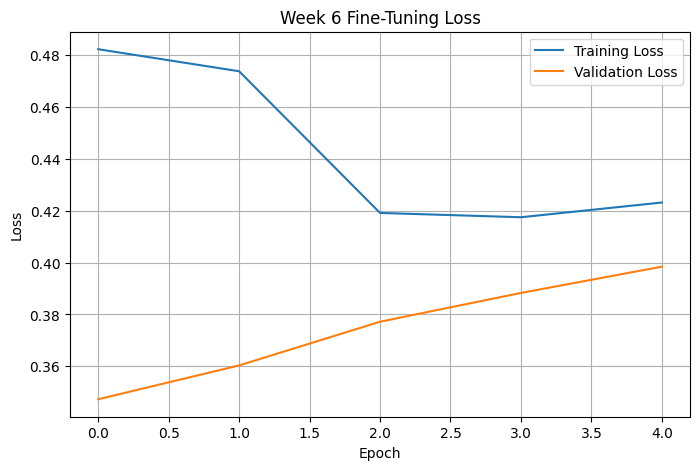

In [36]:
import matplotlib.pyplot as plt

# Accuracy
plt.figure(figsize=(8,5))
plt.plot(history_finetune.history['accuracy'], label='Training Accuracy')
plt.plot(history_finetune.history['val_accuracy'], label='Validation Accuracy')
plt.title("Week 6 Fine-Tuning Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# Loss
plt.figure(figsize=(8,5))
plt.plot(history_finetune.history['loss'], label='Training Loss')
plt.plot(history_finetune.history['val_loss'], label='Validation Loss')
plt.title("Week 6 Fine-Tuning Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

# Week 6 Fine-Tuning Pass 1 Summary

## Final Results

| Metric | Value |
|--------|-------|
| Training Accuracy | **86.55%** |
| Validation Accuracy | **85.94%** |

## Comparison with Feature Extraction

| Model | Validation Accuracy |
|--------|--------------------|
| Feature Extraction | **88.12%** |
| Fine-Tuning Pass 1 | **85.94%** |

The first fine-tuning pass did not improve validation accuracy compared to the feature extraction model. This indicates that the pretrained feature extractor already provided strong representations for the TrashNet dataset. Additional experiments with different hyperparameters may improve fine-tuning performance.

## Conclusion

Week 6 Fine-Tuning Pass 1 was completed successfully. The saved checkpoint will be useful for comparison with later experiments.